In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CallbackList, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *
#from mbt_gym.rewards.RewardFunctions import RunningInventoryPenalty

In [4]:
seed_value = 42
global seed  
seed = seed_value

# Reset seeds for all randomness sources
np.random.seed(seed)
torch.manual_seed(seed)

### Parameters

In [5]:
max_inventory = 20

In [6]:
initial_price = 100
terminal_time = 10.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [7]:
total_arrivals = 30.0
# OU parameters
u0 = 0.0
xi = 1.0

In [8]:
# Replace your compute_psi function with this:
def compute_aux_integral_for_psi():
    """Compute the integral needed to rescale psi, matching Adrien's implementation."""
    # This matches Adrien's compute_integral_related_to_psi
    time_grid = np.linspace(0, terminal_time, n_steps)
    
    def v(t):
        return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))
    
    # Compute exp(γ²/2 * v(t)) for each time point
    integrand_values = np.exp((gamma * sigma * fads_proportion)**2 / 2 * v(time_grid))
    
    # Return T * mean(integrand)
    return terminal_time * np.mean(integrand_values)

# Now compute psi correctly
aux_integral = compute_aux_integral_for_psi()
psi = (total_arrivals * terminal_time - phi * terminal_time) / aux_integral

print(f"aux_integral: {aux_integral}")
print(f"psi value: {psi}")

aux_integral: 10.08990691848612
psi value: 14.866341306397885


In [9]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [10]:
cj_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [11]:
cj_agent = ModifiedCarteaJaimungalMmAgent(env=cj_env)
print(cj_env.model_dynamics
      .midprice_model)


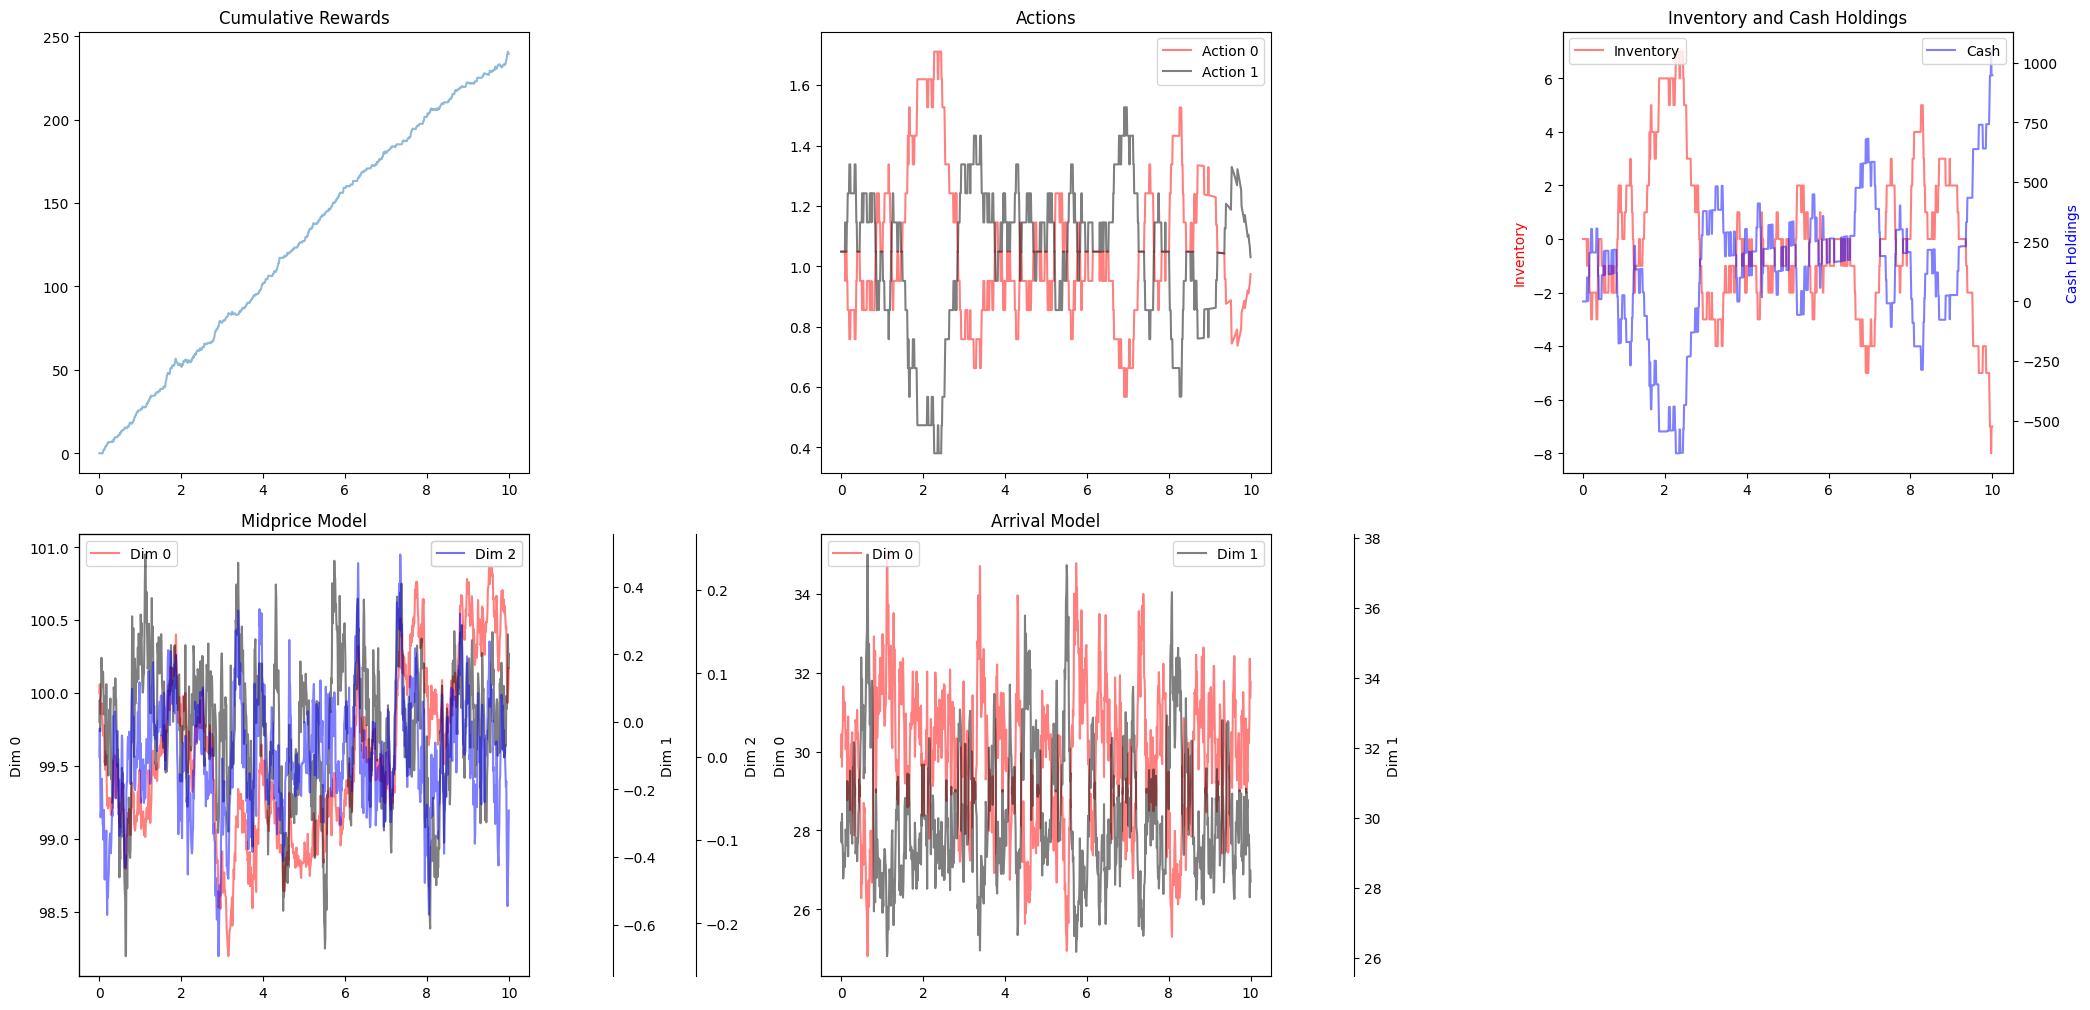

In [12]:
plot_trajectory_extended(cj_env, cj_agent)

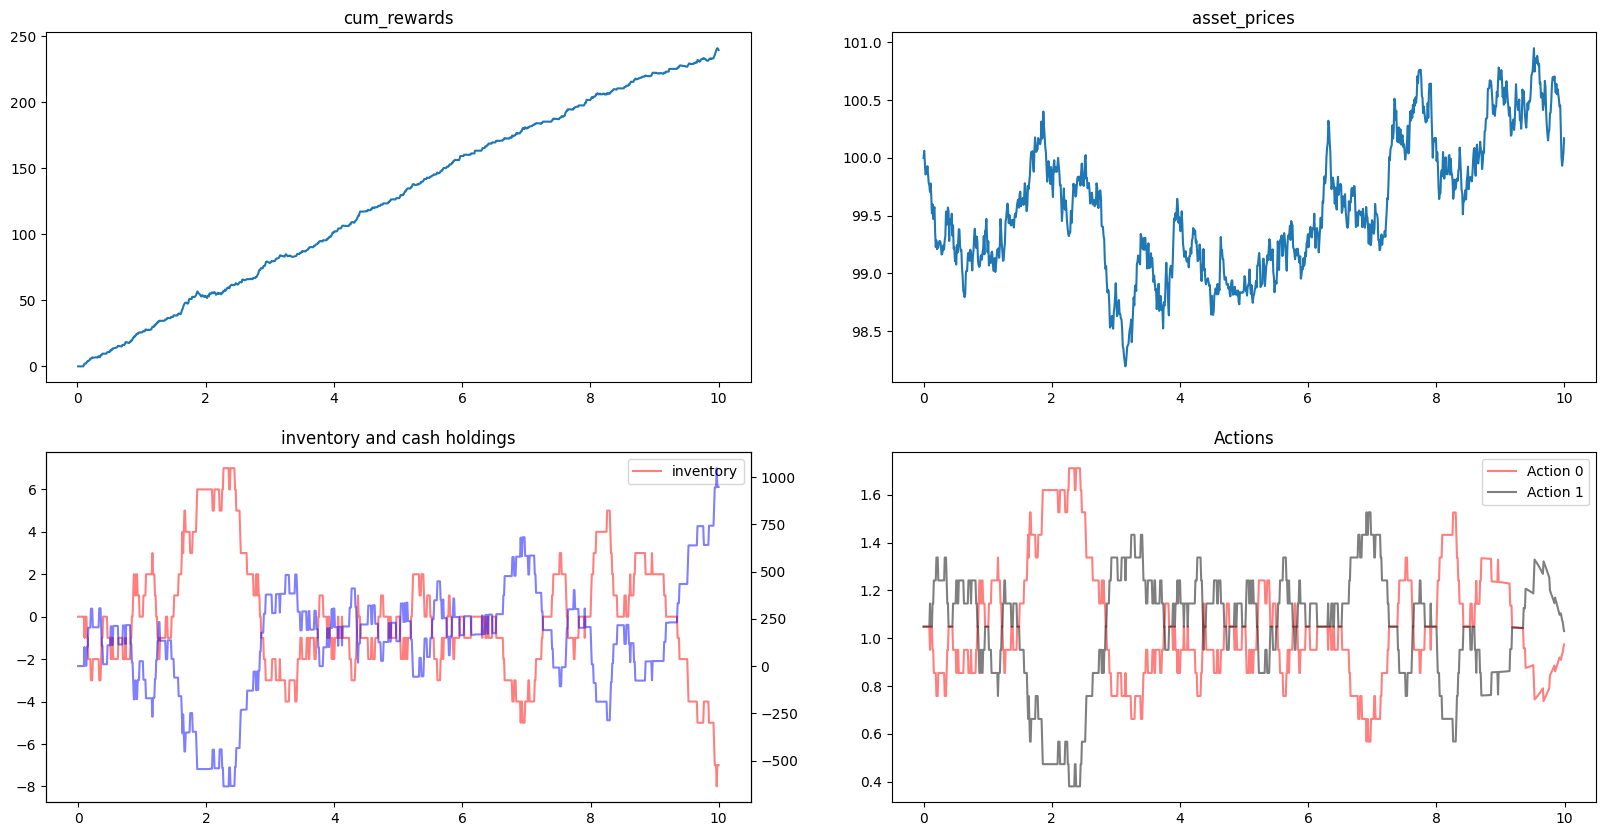

In [13]:
plot_trajectory(cj_env, cj_agent, seed = seed)

In [14]:
num_trajectories = 1000
vec_cj_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_cj = ModifiedCarteaJaimungalMmAgent(env=vec_cj_env)

print(vec_cj_env.model_dynamics
      .midprice_model)

In [15]:
observations_cj, actions_cj, rewards_cj = generate_trajectory(vec_cj_env, vec_cj)

In [16]:
results_cj, fig_cj, total_rewards_cj = generate_results_table_and_hist(vec_env=vec_cj_env,agent=vec_cj)

In [17]:
results_cj

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.093311,210.053825,15.094316,-0.176,3.075227


### Rinforncement Learning

#### Random initial inventory

In [18]:
random_initial_inventory = (-6,5)

#### Random start time 

In [19]:

def make_random_start_time_sampler(terminal_time: float):
    """
    Returns a callable that samples an initial time according to:
      - with probability 0.5: uniform in [0, 0.8 * T]
      - with probability 0.5: uniform in [0.8 * T, 0.99 * T]
    
    Parameters
    ----------
    terminal_time : float
        The terminal time T of the episode.
    
    Returns
    -------
    callable
        A function that samples and returns a random start time.
    """
    def _sample_start_time():
        if np.random.rand() < 0.5:
            # 50% chance: early part of episode
            return np.random.uniform(0.0, 0.8 * terminal_time)
        else:
            # 50% chance: near the end of episode
            return np.random.uniform(0.8 * terminal_time, 0.99 * terminal_time)
    return _sample_start_time

In [20]:
def get_rl_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time
                           )
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [21]:
num_trajectories = 1000
reduced_training_indices = [INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX]
rl_env = ReduceStateSizeWrapper(get_rl_env(num_trajectories), reduced_training_indices)
#rl_env = NormaliseASObservation(rl_env)
sb_rl_env = StableBaselinesTradingEnvironment(trading_env=rl_env)

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):


### PPO

In [22]:
total_steps = 100_000_000  
#eval_freq = total_steps // 10 
n_eval_episodes = 256

use_normalized_agent = False

In [23]:
# Monitor sb_rl_env
sb_rl_env = VecMonitor(sb_rl_env)

# Generate timestamp string
run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
experiment_name = "CjMm_PPO_prove_new_terminal_penalty"
# Paths with timestamp
tensorboard_logdir = f"./CJ_models/tensorboard/PPO-learning/{experiment_name}/{run_id}/"
best_model_path = f"./CJ_models/PPO-best/{experiment_name}/{run_id}/"

In [24]:
print(sb_rl_env.action_space)
print(sb_rl_env.action_space.low, sb_rl_env.action_space.high)

Box(0.0, 4.6051702, (2,), float32)
[0. 0.] [4.6051702 4.6051702]


In [25]:
print(sb_rl_env)

In [26]:
from stable_baselines3.common.callbacks import BaseCallback

class EntropyDecayCallback(BaseCallback):
    def __init__(self, initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=10_000_000, verbose=0):
        super().__init__(verbose)
        self.initial_ent_coef = initial_ent_coef
        self.final_ent_coef = final_ent_coef
        self.decay_steps = decay_steps

    def _on_step(self) -> bool:
        progress = min(1.0, self.num_timesteps / self.decay_steps)
        new_ent_coef = self.initial_ent_coef * (1 - progress) + self.final_ent_coef * progress
        self.model.ent_coef = new_ent_coef
        return True

In [27]:
#policy_kwargs = dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])])

policy_kwargs = dict(
    activation_fn=nn.Tanh,                 
    net_arch=[dict(pi=[256, 256], vf=[256, 256])]
)
PPO_params = {"policy":'MlpPolicy', "env": sb_rl_env, "verbose":1, 
              "policy_kwargs":policy_kwargs, 
              "tensorboard_log":tensorboard_logdir,
              "n_epochs":3,
              "batch_size": int(n_steps * num_trajectories / 10), 
              "n_steps": int(n_steps),
              #"ent_coef": 0.05 # added ent_coef to encourage exploration
                }

#eval_env = get_rl_env(num_trajectories=1)
#eval_env.initial_inventory = 0
callback_params = dict(eval_env=sb_rl_env, n_eval_episodes=n_eval_episodes,
                       #eval_freq=eval_freq,
                       best_model_save_path = best_model_path, 
                       deterministic=True)

#entropy_decay_callback = EntropyDecayCallback(initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=20_000_000)
#callback = CallbackList([EvalCallback(**callback_params), entropy_decay_callback])

callback = EvalCallback(**callback_params)
model = PPO(**PPO_params, device="cpu")

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


Using cpu device


### SAC

In [28]:
# # Monitor sb_env
# sb_env = VecMonitor(sb_env)

# # Generate timestamp string
# run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# experiment_name = "CjMm_SAC_30_000_000steps" 

# # Paths with timestamp
# tensorboard_logdir = f"./CJ_models/tensorboard/SAC-learning/{experiment_name}/{run_id}/"
# best_model_path = f"./CJ_models/SAC-best/{experiment_name}/{run_id}/"

In [29]:
# policy_kwargs = dict(net_arch=dict(pi=[256, 256], qf=[256, 256]))

# # SAC is an off-policy algorithm and uses a replay buffer. Its parameters are different.
# SAC_params = {
#     "policy": 'MlpPolicy', 
#     "env": sb_env, 
#     "verbose": 1, 
#     "tensorboard_log": tensorboard_logdir,
#     "policy_kwargs": policy_kwargs,
    
#     # --- New parameters specific to SAC ---
#     "buffer_size": 1_000_000,     # Size of the replay buffer. 1M is a good default.
#     "batch_size": 256,            # Number of samples from the buffer for each update.
#     "learning_starts": 10000,     # How many steps to collect before starting to learn.
#     "gamma": 0.99,                # Discount factor.
#     "tau": 0.005,                 # The soft update coefficient for target networks.
#     "learning_rate": 3e-4,        # Learning rate, often 0.0003 for SAC.
# }

# # The callback setup remains exactly the same!
# callback_params = dict(eval_env=sb_env, n_eval_episodes=2048,
#                        best_model_save_path=best_model_path, 
#                        deterministic=True)

# callback = EvalCallback(**callback_params)

# # <-- CHANGED: Instantiate the SAC model
# model = SAC(**SAC_params, device="cpu")


### Training

In [30]:
print(sb_rl_env.observation_space)

Box([-20.           0.         -12.51928806], [ 20.          10.         112.51928711], (3,), float64)


In [31]:
model.learn(total_timesteps = total_steps, callback=callback) 

Logging to ./CJ_models/tensorboard/PPO-learning/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -17.7    |
| time/              |          |
|    fps             | 391205   |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 1000000  |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -6.36       |
| time/                   |             |
|    fps                  | 117730      |
|    iterations           | 2           |
|    time_elapsed         | 16          |
|    total_timesteps      | 2000000     |
| train/                  |             |
|    approx_kl            | 0.003508995 |
|    clip_fraction        | 0.0175      |
|    clip_range           | 0.2         |
|   

### Visualization

In [32]:



def get_rl_env_visualization(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time
            )
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory = max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [33]:
rl_env_visualization = get_rl_env_visualization(num_trajectories=5)

In [34]:
from mbt_gym.agents.SbAgent import SbAgent
ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_visualization, use_normalized_agent=use_normalized_agent)

Generating RL trajectory plot...
env.observation_space: Box([-1.1251929e+05 -2.0000000e+01  0.0000000e+00 -1.2519288e+01
 -1.0000000e+01 -1.0000000e+01  0.0000000e+00  0.0000000e+00], [1.1251929e+05 2.0000000e+01 1.0000000e+01 1.1251929e+02 1.0000000e+01
 1.0000000e+01 6.0000000e+01 6.0000000e+01], (8,), float32)
env.action_space: Box(0.0, 4.6051702, (2,), float32)


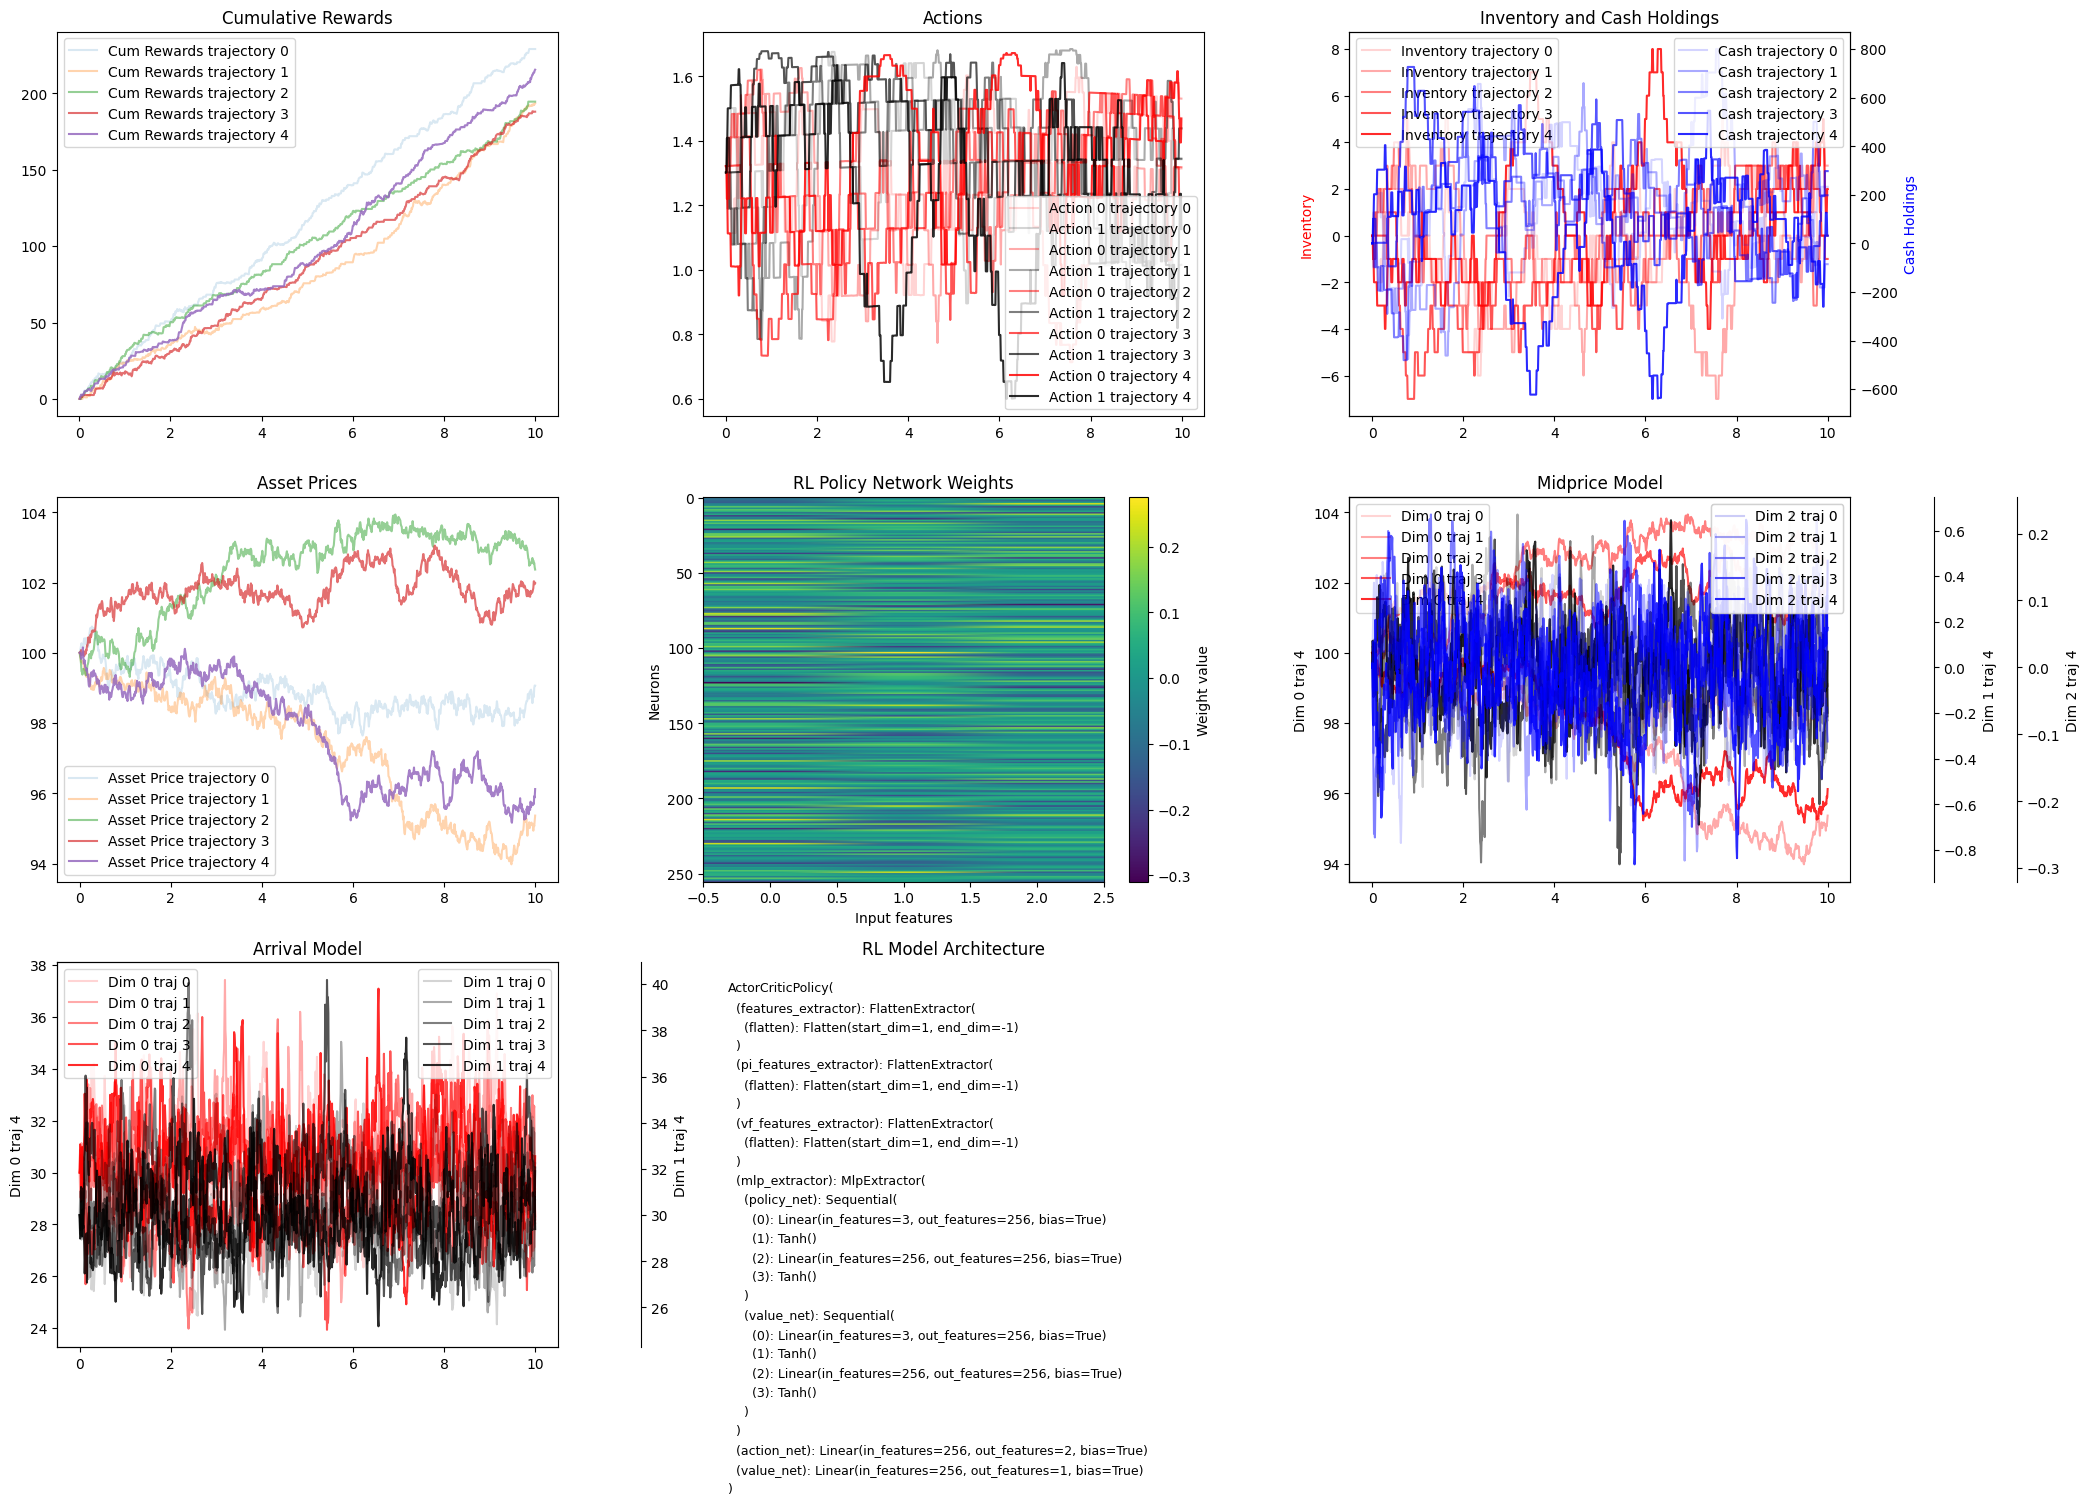

Plot saved to ./CJ_models/PPO-best/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/trajectory_plot.png


In [35]:
# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Create the plot
fig = plot_rl_trajectory_extended(rl_env_visualization, ppo_agent)

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "trajectory_plot.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

In [36]:
rl_env_evaluation = get_rl_env_visualization(num_trajectories=1000)

In [37]:
# step 1: evaluate
observations_rl, actions_rl, rewards_rl = generate_trajectory_rl(env=rl_env_evaluation, rl_agent=ppo_agent)

In [38]:
results_rl, fig_rl, total_rewards_rl = generate_results_table_and_hist_rl(vec_env=rl_env_evaluation, rl_agent=ppo_agent)

In [39]:
results_rl

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
RL Agent,2.61842,204.828829,16.84964,0.064,2.306492


## Comparing the learnt policy to the optimal policy

In [40]:
# For the StableBaselinesTradingEnvironment
print("SB Environment Action Space:")
print(f"Shape: {sb_rl_env.action_space}")
print(f"Low bounds: {sb_rl_env.action_space.low}")
print(f"High bounds: {sb_rl_env.action_space.high}")

# For the original trading environment
print("\nOriginal Trading Environment Action Space:")
print(f"Shape: {rl_env.action_space}")
print(f"Low bounds: {rl_env.action_space.low}")
print(f"High bounds: {rl_env.action_space.high}")

SB Environment Action Space:
Shape: Box(0.0, 4.6051702, (2,), float32)
Low bounds: [0. 0.]
High bounds: [4.6051702 4.6051702]

Original Trading Environment Action Space:
Shape: Box(0.0, 4.6051702, (2,), float32)
Low bounds: [0. 0.]
High bounds: [4.6051702 4.6051702]


In [41]:
def normalize_inventory(inventories, max_inventory, use_normalized=False, inverse=False):
    if not use_normalized:
        return inventories

    inventory_low = -max_inventory
    gradient_inventory = (max_inventory - inventory_low) / 2  # equals max_inventory

    if inverse:
        # Denormalize: from [-1, 1] back to original scale
        return (inventories + 1) * gradient_inventory + inventory_low
    else:
        # Normalize: from [-max_inventory, max_inventory] to [-1, 1]
        return (inventories - inventory_low) / gradient_inventory - 1

In [42]:
inventories = np.arange(-4,5,1)
inventories_normalised = normalize_inventory(inventories, max_inventory, use_normalized=use_normalized_agent, inverse=False)

In [43]:
ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_evaluation, use_normalized_agent=use_normalized_agent) 

In [44]:
bid_actions = []
ask_actions = []
for inventory in inventories_normalised:
    if use_normalized_agent:
        state = np.array([[inventory,0,0]])
    else:
        state = np.array([[inventory,0.5,100]])
    bid_action, ask_action = ppo_agent.get_action(state).reshape(-1)
    bid_actions.append(bid_action)
    ask_actions.append(ask_action)    

In [45]:
cj_agent = ModifiedCarteaJaimungalMmAgent(env=get_closed_form_env())

In [46]:
# Get the Cartea Jaimungal action
cj_bid_actions = []
cj_ask_actions = []
for inventory in inventories:
    bid_action, ask_action = cj_agent.get_action(np.array([[0,inventory,0.5]])).reshape(-1)
    cj_bid_actions.append(bid_action)
    cj_ask_actions.append(ask_action)

Policy comparison plot saved to ./CJ_models/PPO-best/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/policy_comparison.png


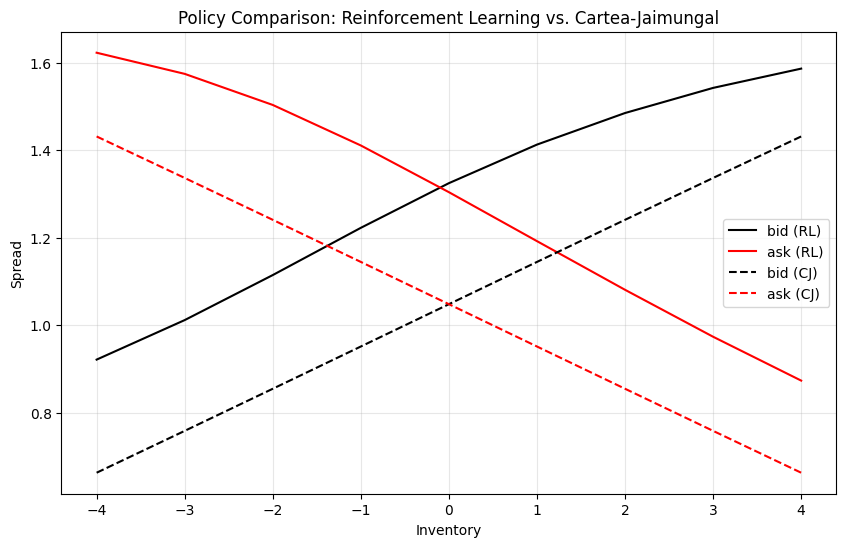

In [47]:
# Create a policy comparison plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(inventories, bid_actions, label="bid (RL)", color="k")
ax.plot(inventories, ask_actions, label="ask (RL)", color="r")
ax.plot(inventories, cj_bid_actions, label="bid (CJ)", color="k", linestyle="--")
ax.plot(inventories, cj_ask_actions, label="ask (CJ)", color="r", linestyle="--")
ax.legend()
ax.set_xlabel("Inventory")
ax.set_ylabel("Spread")
ax.set_title("Policy Comparison: Reinforcement Learning vs. Cartea-Jaimungal")
ax.grid(alpha=0.3)

# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Save the figure to the best model path
policy_comparison_filename = os.path.join(best_model_path, "policy_comparison.png")
fig.savefig(policy_comparison_filename, dpi=300, bbox_inches='tight')
print(f"Policy comparison plot saved to {policy_comparison_filename}")

### Dependence of policy on time

In [48]:


# Function to create the plot comparing PPO and CJ agents
def plot_policy_time_dependence(ppo_agent, cj_agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  # 0 to 30 seconds
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  # RL bid
    ax2 = plt.subplot(gs[0, 1])  # CJ bid
    ax3 = plt.subplot(gs[1, 0])  # RL ask
    ax4 = plt.subplot(gs[1, 1])  # CJ ask
    
    price = 100.0  # Fixed price for evaluation
    if use_normalized_agent:
        price_normalized = 0  # Normalize price to [-1, 1]
    else:
        price_normalized = price  # Assuming no normalization for price in this context

    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        cj_bids = []
        cj_asks = []
        
        inv_normalised = normalize_inventory(inv, max_inventory, use_normalized=use_normalized_agent, inverse=False)

        # For each time point
        for t in times:
            if use_normalized_agent:
                normalized_time = (t) / (1/2) - 1
            else:   
                normalized_time = t
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv_normalised, normalized_time, price_normalized]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)
            
            # Get CJ agent's actions
            cj_bid, cj_ask = cj_agent.get_action(np.array([[0, inv, t]])).reshape(-1)
            cj_bids.append(cj_bid)
            cj_asks.append(cj_ask)
        
        # Plot the data
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, cj_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, cj_asks, label=f"Inventory = {inv}", color=colors[inv])
    
    # Setting titles and labels
    ax1.set_title("RL δ^bid")
    ax2.set_title("CJP δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("CJP δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    # Add a legend to the first subplot
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    # Add an overall figure caption
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus CarteaJaimungalAgent as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()

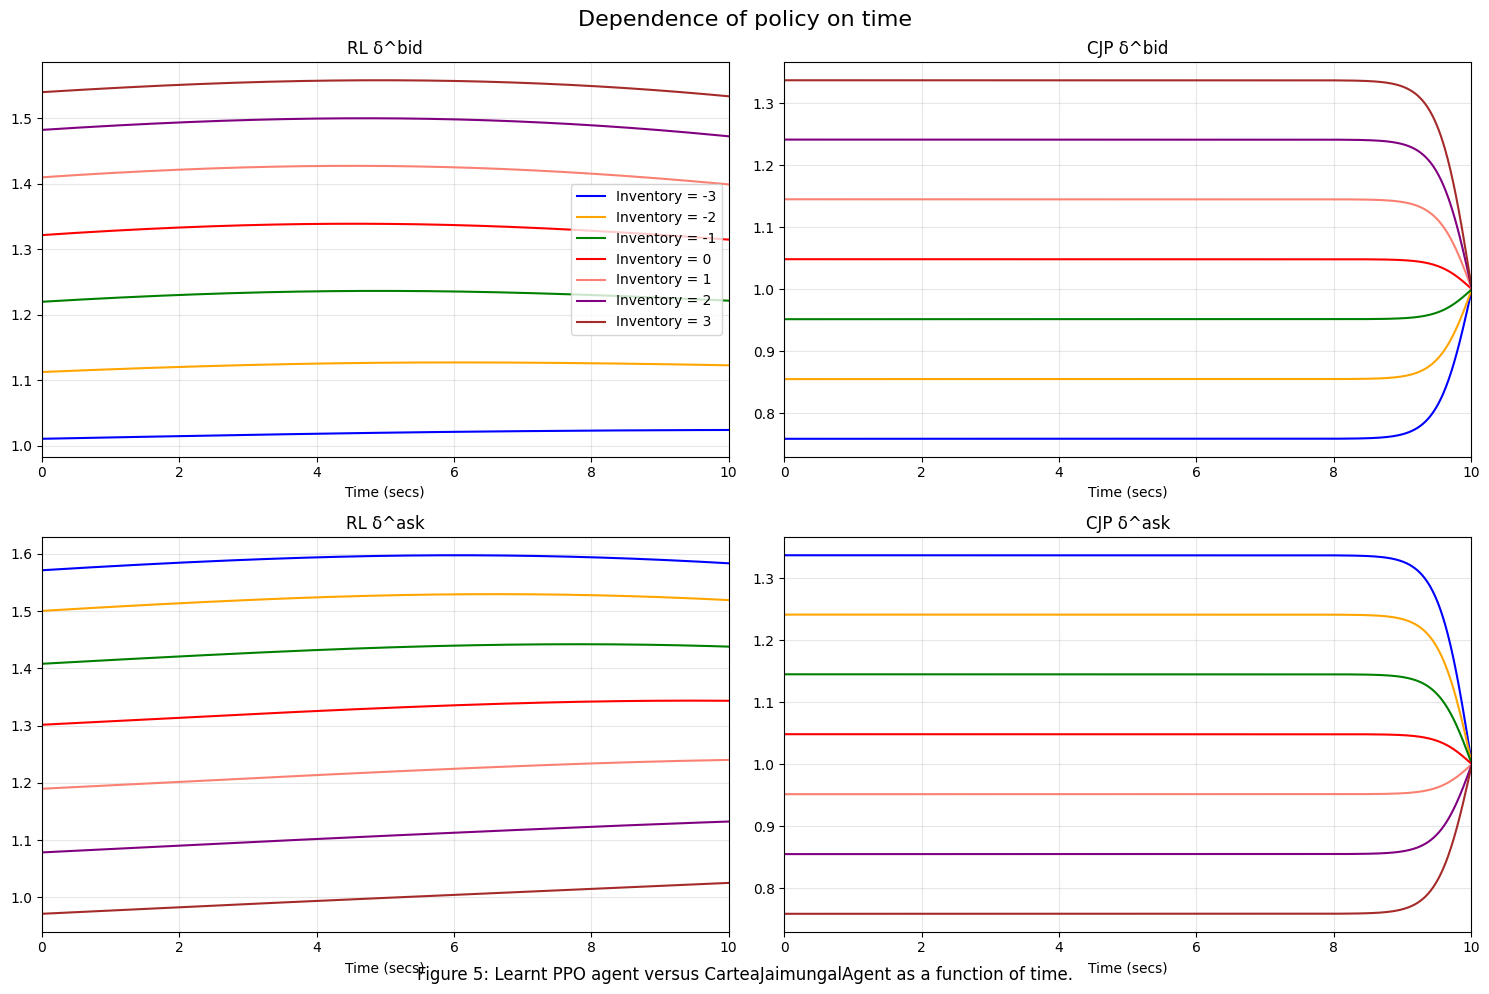

In [49]:
plot_policy_time_dependence(ppo_agent, cj_agent)

In [50]:
def plot_policy_time_dependence(ppo_agent, cj_agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  # 0 to 30 seconds
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  # RL bid
    ax2 = plt.subplot(gs[0, 1])  # CJ bid
    ax3 = plt.subplot(gs[1, 0])  # RL ask
    ax4 = plt.subplot(gs[1, 1])  # CJ ask
    
    price = 100.0  # Fixed price for evaluation
    if use_normalized_agent:
        price_normalized = 0  # Normalize price to [-1, 1]
    else:
        price_normalized = price  # Assuming no normalization for price in this context

        # Track global min/max for all plots
    global_min = float('inf')
    global_max = float('-inf')
    
    # Store all data to plot later
    all_data = []

    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        cj_bids = []
        cj_asks = []
        
        inv_normalised = normalize_inventory(inv, max_inventory, use_normalized=use_normalized_agent, inverse=False)

        # For each time point
        for t in times:
            if use_normalized_agent:
                normalized_time = (t) / (1/2) - 1
            else:   
                normalized_time = t
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv_normalised, normalized_time, price_normalized]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)
            
            # Get CJ agent's actions
            cj_bid, cj_ask = cj_agent.get_action(np.array([[0, inv, t]])).reshape(-1)
            cj_bids.append(cj_bid)
            cj_asks.append(cj_ask)
        
        # Update global min/max
        global_min = min(global_min, min(rl_bids), min(rl_asks), min(cj_bids), min(cj_asks))
        global_max = max(global_max, max(rl_bids), max(rl_asks), max(cj_bids), max(cj_asks))
        
        # Store data for later plotting
        all_data.append((inv, rl_bids, rl_asks, cj_bids, cj_asks))
    
    # Now plot all data with the same y-axis scale
    for inv, rl_bids, rl_asks, cj_bids, cj_asks in all_data:
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, cj_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, cj_asks, label=f"Inventory = {inv}", color=colors[inv])
    
    # Apply the same y-axis limits to all subplots
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(global_min, global_max)
    
    # Setting titles and labels
    ax1.set_title("RL δ^bid")
    ax2.set_title("CJP δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("CJP δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    # Add a legend to the first subplot
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    # Add an overall figure caption
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus CarteaJaimungalAgent as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()
    return fig

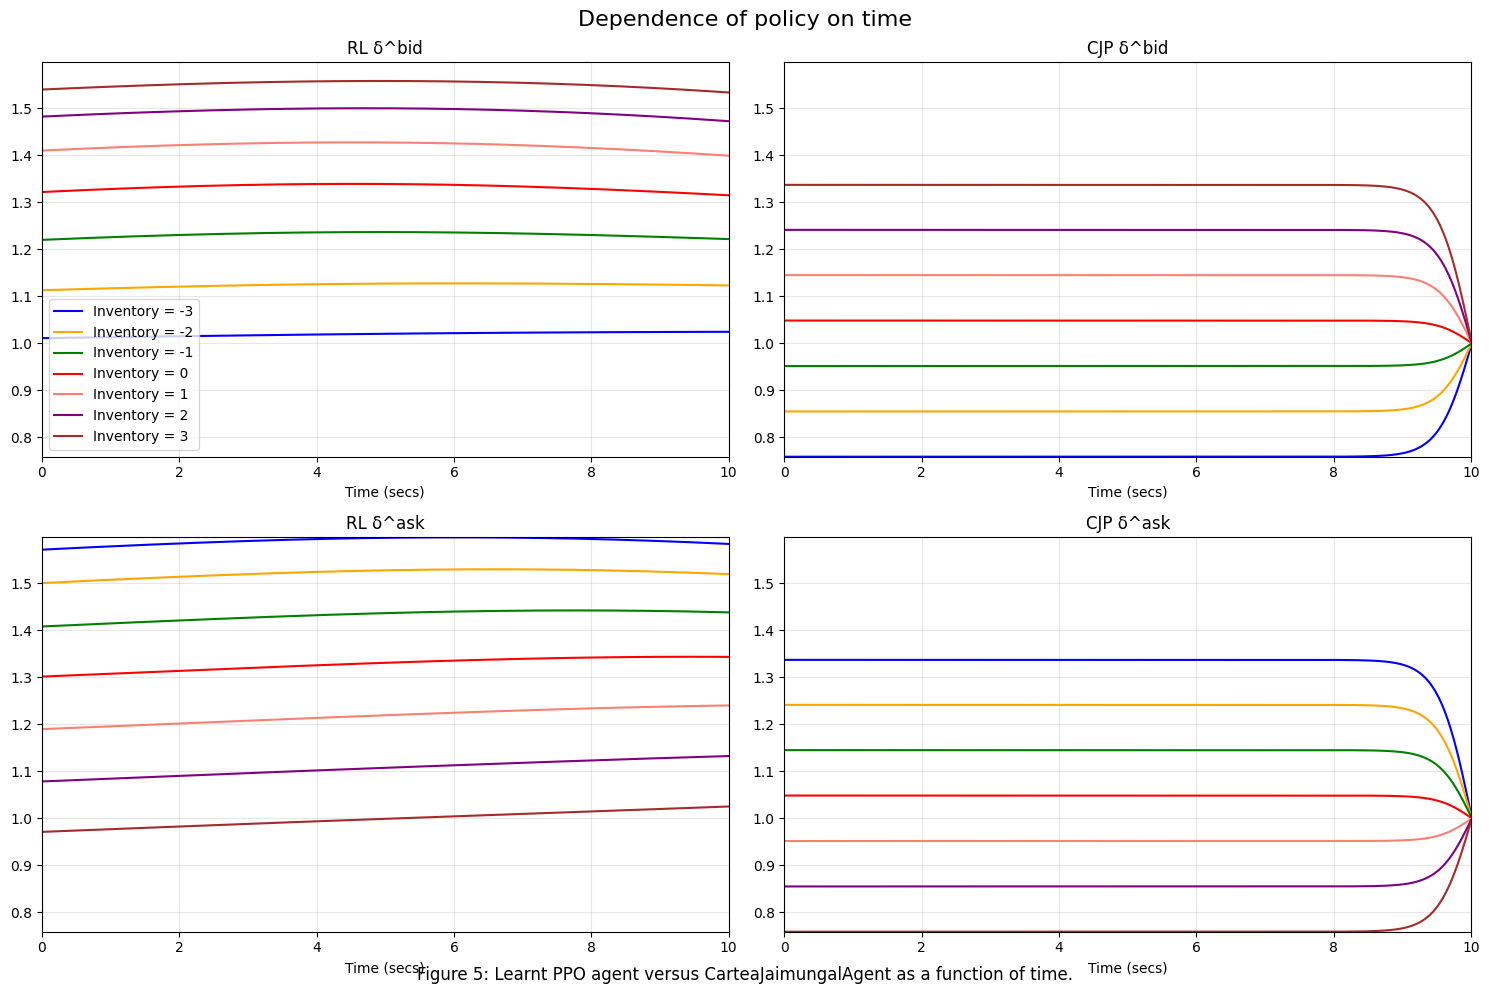

Plot saved to ./CJ_models/PPO-best/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/policy_time_dependence.png


In [51]:
# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Create the plot
fig = plot_policy_time_dependence(ppo_agent, cj_agent)

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "policy_time_dependence.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

In [52]:
total_rewards = rewards_rl.sum(axis=-1).reshape(-1)
print('mean: ',np.mean(total_rewards))
print('median: ',np.median(total_rewards))
print('std: ',np.std(total_rewards))

mean:  204.8520061169588
median:  204.78946144997497
std:  16.642267089519954


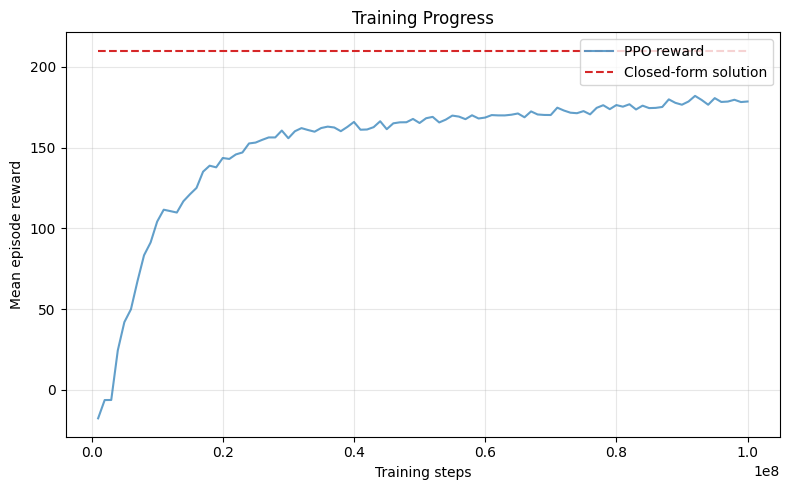

Plot saved to ./CJ_models/PPO-best/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/Training_process_rollout_reward.png


In [56]:
# Load the event file
event_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/PPO_1/events.out.tfevents.1762338168.MacBookAir.lan.26730.0"
# Load the data
ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()
# Extract the rollout/ep_rew_mean data
tag = "rollout/ep_rew_mean"
events = ea.Scalars(tag)
steps = [event.step for event in events]
rewards = [event.value for event in events]

# Plot the rewards
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the rewards
ax.plot(steps, rewards, '-', color='tab:blue', label='PPO reward', alpha=0.7)

# Add the baseline from Cartea-Jaimungal
y_line = float(results_cj["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(steps), xmax=max(steps), 
          linestyles='--', color='tab:red',
          label='Closed-form solution')

# Formatting
plt.grid(alpha=0.3)
plt.xlabel('Training steps')
plt.ylabel('Mean episode reward')
plt.title('Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "Training_process_rollout_reward.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss', 'eval/mean_ep_length', 'eval/mean_reward'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


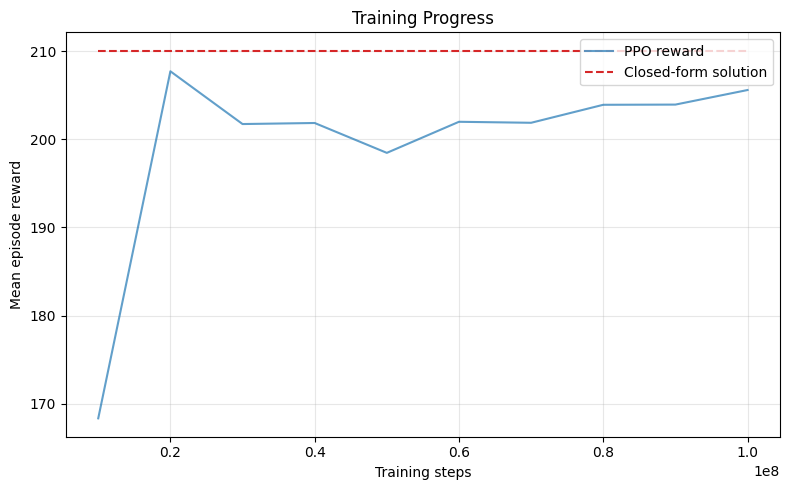

Plot saved to ./CJ_models/PPO-best/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/Training_process_eval_reward.png


In [57]:
# Load the event file
event_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/PPO_1/events.out.tfevents.1762338168.MacBookAir.lan.26730.0"
# Load the data
ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()
# Extract the eval/ep_rew_mean data
tag = "eval/mean_reward"
print(ea.Tags())
events = ea.Scalars(tag)
steps = [event.step for event in events]
rewards = [event.value for event in events]

# Plot the rewards
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the rewards
ax.plot(steps, rewards, '-', color='tab:blue', label='PPO reward', alpha=0.7)

# Add the baseline from Cartea-Jaimungal
y_line = float(results_cj["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(steps), xmax=max(steps), 
          linestyles='--', color='tab:red',
          label='Closed-form solution')

# Formatting
plt.grid(alpha=0.3)
plt.xlabel('Training steps')
plt.ylabel('Mean episode reward')
plt.title('Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "Training_process_eval_reward.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

Available tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss', 'eval/mean_ep_length', 'eval/mean_reward'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


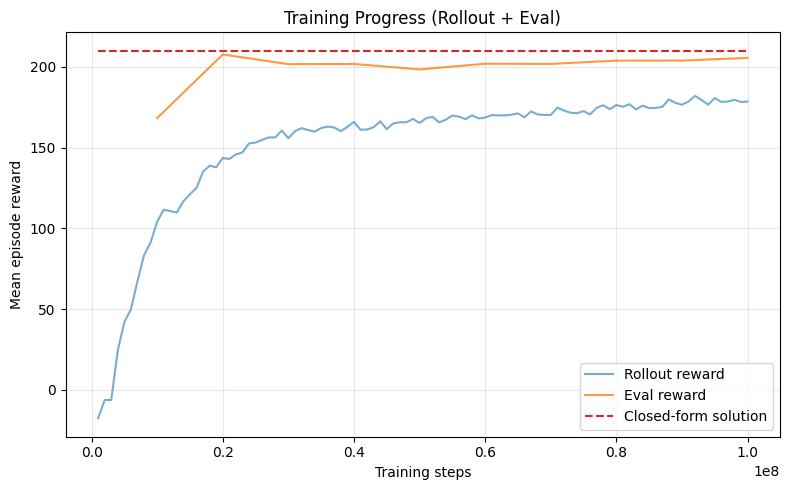

Plot saved to ./CJ_models/PPO-best/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/Training_process_rewards.png


In [59]:
# === Load rollout rewards ===
rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_prove_new_terminal_penalty/2025-11-05_11-22-47/PPO_1/events.out.tfevents.1762338168.MacBookAir.lan.26730.0"

ea_rollout = event_accumulator.EventAccumulator(rollout_file)
ea_rollout.Reload()

# === Load eval rewards ===
eval_file = rollout_file  # same file if training and eval in same run
ea_eval = event_accumulator.EventAccumulator(eval_file)
ea_eval.Reload()

# Extract rollout and eval data
rollout_tag = "rollout/ep_rew_mean"
eval_tag = "eval/mean_reward"

# Make sure both tags exist
print("Available tags:", ea_rollout.Tags())

rollout_events = ea_rollout.Scalars(rollout_tag)
eval_events = ea_eval.Scalars(eval_tag)

rollout_steps = [e.step for e in rollout_events]
rollout_rewards = [e.value for e in rollout_events]

eval_steps = [e.step for e in eval_events]
eval_rewards = [e.value for e in eval_events]

# === Plot both ===
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(rollout_steps, rollout_rewards, '-', color='tab:blue', label='Rollout reward', alpha=0.6)
ax.plot(eval_steps, eval_rewards, '-', color='tab:orange', label='Eval reward', alpha=0.8)

# Add baseline line
y_line = float(results_cj["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(rollout_steps + eval_steps), xmax=max(rollout_steps + eval_steps),
          linestyles='--', color='tab:red', label='Closed-form solution')

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Training Progress (Rollout + Eval)')
ax.legend()
plt.tight_layout()
plt.show()

# Save the figure
plot_filename = os.path.join(best_model_path, "Training_process_rewards.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")
